# MLOps Pipeline: Image Classification
### Breast Ultrasound Dataset — Normal / Benign / Malignant

```bash
pip install wandb datasets Pillow scikit-learn torch torchvision
```

**Pipeline:**
```
Load images  →  Explore  →  Preprocess  →  Train CNN  →  Track with W&B  →  Load & serve
```

> **Setup:** Create a free account at https://wandb.ai then run the login cell below.

---
## Setup — Install & Login

In [ ]:
import os
from huggingface_hub import login
from google.colab import userdata

# Best practice: Store your HF_TOKEN in Colab's 'Secrets' (key icon on the left)
# and retrieve it like this:
# from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

# Alternatively, set it manually for this session:
# os.environ['HF_TOKEN'] = "YOUR_HUGGING_FACE_API_KEY_HERE"

# login(token=os.environ['HF_TOKEN'])

In [ ]:
!pip install wandb datasets Pillow scikit-learn torch torchvision --quiet

In [ ]:

import wandb

# Load API key from Colab Secrets (never hardcode keys in notebooks)
import os
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")

wandb.login(key=os.environ["WANDB_API_KEY"])
print("Logged in to W&B")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tibajoel90 (tibajoel90-sunbird-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in to W&B


---
## Stage 1 — Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
from datasets import load_dataset

#ds = load_dataset("ShivamRaisharma/breastcancer")
ds = load_dataset("ShivamRaisharma/breastcancer", cache_dir="/content/hf_cache")

ds.save_to_disk("/content/drive/MyDrive/indabax_dataset/breastcancer_dataset")
print("Saved to Drive!")

# The dataset only has a train split — we'll create our own val/test split below
print(ds)
print("\nFirst example keys:", ds['train'][0].keys())

In [ ]:
from datasets import load_from_disk

ds = load_from_disk("/content/drive/MyDrive/indabax_dataset/breastcancer_dataset")

print(ds)
print("\nFirst example keys:", ds['train'][0].keys())

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1578
    })
})

First example keys: dict_keys(['image', 'label'])


---
## Stage 2 — Explore

Classes    : ['benign', 'malignant', 'normal']
Distribution:
  benign      :  891 images
  malignant   :  421 images
  normal      :  266 images


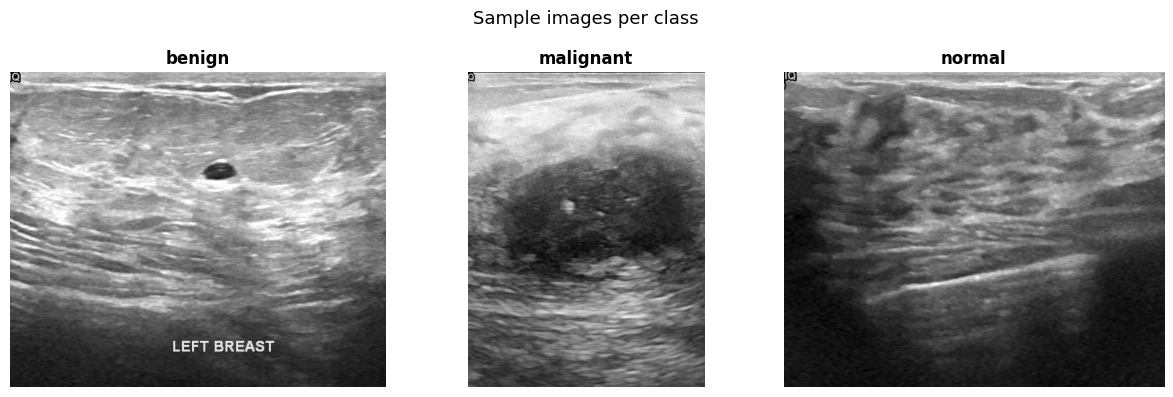

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

train = ds['train']

LABEL_FIELD = 'label'
IMAGE_FIELD = 'image'

labels      = [ex[LABEL_FIELD] for ex in train]
label_names = train.features[LABEL_FIELD].names  # ['benign', 'malignant', 'normal']
counts      = Counter(labels)

print(f"Classes    : {label_names}")
print(f"Distribution:")
for idx, name in enumerate(label_names):
    print(f"  {name:12s}: {counts[idx]:4d} images")

# ── Plot sample images per class ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(label_names), figsize=(12, 4))
for ax, (idx, name) in zip(axes, enumerate(label_names)):
    for ex in train:
        if ex[LABEL_FIELD] == idx:
            ax.imshow(ex[IMAGE_FIELD], cmap='gray')
            ax.set_title(name, fontsize=12, fontweight='bold')
            ax.axis('off')
            break
plt.suptitle("Sample images per class", fontsize=13)
plt.tight_layout()
plt.show()

---
## Stage 3 — Preprocess & Split

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

IMG_SIZE    = 128
BATCH_SIZE  = 16
NUM_CLASSES = len(label_names)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class UltrasoundDataset(Dataset):
    def __init__(self, examples, transform):
        self.examples  = examples
        self.transform = transform

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex    = self.examples[idx]
        image = ex[IMAGE_FIELD].convert('L')
        return self.transform(image), ex[LABEL_FIELD]

# Stratified 70 / 15 / 15 split
indices = list(range(len(train)))
train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                        random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                      random_state=42, stratify=temp_labels)

train_data = [train[i] for i in train_idx]
val_data   = [train[i] for i in val_idx]
test_data  = [train[i] for i in test_idx]

train_loader = DataLoader(UltrasoundDataset(train_data, train_transform),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(UltrasoundDataset(val_data,   eval_transform),
                           batch_size=BATCH_SIZE)
test_loader  = DataLoader(UltrasoundDataset(test_data,  eval_transform),
                           batch_size=BATCH_SIZE)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 1104 | Val: 237 | Test: 237


---
## Stage 4 — Define Model

ResNet - Heavier Model

In [ ]:
# import torch.nn as nn
# from torchvision import models

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# def build_model(num_classes: int):
#     model = models.resnet18(weights='IMAGENET1K_V1')
#     model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#     model.fc    = nn.Linear(model.fc.in_features, num_classes)
#     return model.to(device)

# model = build_model(NUM_CLASSES)
# print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Mobilenetv2 - lighter model

In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def build_model(num_classes: int):
    """MobileNetV2 pretrained on ImageNet, adapted for grayscale input and 3-class output.
    Lighter and faster than ResNet-18 with similar accuracy on small datasets.
    """
    model = models.mobilenet_v2(weights='IMAGENET1K_V1')

    # Grayscale → adapt first conv from 3 channels to 1
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

    # Replace classifier for our number of classes
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    return model.to(device)

model = build_model(NUM_CLASSES)
print(f"Model ready. Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 93.5MB/s]


Model ready. Trainable params: 2,227,139


In [ ]:
!pip install torchinfo --quiet

from torchinfo import summary

# Pass a dummy input matching your actual input shape: (batch, channels, height, width)
summary(model, input_size=(1, 1, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 3]                    --
├─Sequential: 1-1                                  [1, 1280, 4, 4]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 64, 64]           --
│    │    └─Conv2d: 3-1                            [1, 32, 64, 64]           288
│    │    └─BatchNorm2d: 3-2                       [1, 32, 64, 64]           64
│    │    └─ReLU6: 3-3                             [1, 32, 64, 64]           --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           896
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           5,136
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-6   

---
## Stage 5 — Train & Track with Weights & Biases

After running this cell, click the **W&B run link** printed in the output.
You'll see live loss curves, accuracy charts, and all hyperparameters in your browser.

ResNet

In [ ]:
# import wandb
# from torch.optim import Adam
# from torch.optim.lr_scheduler import StepLR

# # ── Hyperparameters ───────────────────────────────────────────────────────
# config = {
#     "model":       "resnet18",
#     "epochs":      3,
#     "lr":          1e-4,
#     "batch_size":  BATCH_SIZE,
#     "img_size":    IMG_SIZE,
#     "num_classes": NUM_CLASSES,
#     "step_size":   5,
# }

# # ── Init W&B run ──────────────────────────────────────────────────────────
# # project= groups all your runs together on wandb.ai
# # config= logs all hyperparameters automatically
# run = wandb.init(
#     project="breast-ultrasound-classification",
#     name="resnet18-finetune",
#     config=config
# )

# # Use config from wandb (allows sweep overrides later)
# cfg = wandb.config

# criterion = nn.CrossEntropyLoss()
# optimizer = Adam(model.parameters(), lr=cfg.lr)
# scheduler = StepLR(optimizer, step_size=cfg.step_size, gamma=0.5)

# def evaluate(loader):
#     model.eval()
#     correct, total, loss_sum = 0, 0, 0.0
#     with torch.no_grad():
#         for images, labels_batch in loader:
#             images, labels_batch = images.to(device), labels_batch.to(device)
#             outputs   = model(images)
#             loss_sum += criterion(outputs, labels_batch).item()
#             correct  += (outputs.argmax(1) == labels_batch).sum().item()
#             total    += labels_batch.size(0)
#     return loss_sum / len(loader), correct / total

# # ── Training loop ─────────────────────────────────────────────────────────
# for epoch in range(1, cfg.epochs + 1):
#     model.train()
#     train_loss_sum, train_correct, train_total = 0.0, 0, 0

#     for images, labels_batch in train_loader:
#         images, labels_batch = images.to(device), labels_batch.to(device)
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss    = criterion(outputs, labels_batch)
#         loss.backward()
#         optimizer.step()

#         train_loss_sum  += loss.item()
#         train_correct   += (outputs.argmax(1) == labels_batch).sum().item()
#         train_total     += labels_batch.size(0)

#     scheduler.step()

#     train_loss = train_loss_sum / len(train_loader)
#     train_acc  = train_correct / train_total
#     val_loss, val_acc = evaluate(val_loader)

#     # ── Log to W&B — this is what appears live in the browser ─────────
#     wandb.log({
#         "epoch":      epoch,
#         "train_loss": round(train_loss, 4),
#         "train_acc":  round(train_acc,  4),
#         "val_loss":   round(val_loss,   4),
#         "val_acc":    round(val_acc,    4),
#     })

#     print(f"Epoch {epoch:2d}/{cfg.epochs} "
#           f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f}  "
#           f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

# # ── Final test evaluation ─────────────────────────────────────────────────
# test_loss, test_acc = evaluate(test_loader)
# wandb.log({"test_loss": test_loss, "test_acc": test_acc})
# print(f"\nTest accuracy: {test_acc:.4f}")

# # ── Save model as a W&B artifact ──────────────────────────────────────────
# torch.save(model.state_dict(), "resnet18_ultrasound.pt")
# artifact = wandb.Artifact(name="ultrasound-model", type="model")
# artifact.add_file("resnet18_ultrasound.pt")
# run.log_artifact(artifact)

# wandb.finish()
# print("\n✅ Run complete. View it at https://wandb.ai")

MobileNetv2

In [ ]:
import wandb
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

config = {
    "model":       "mobilenetv2",   # ← updated
    "epochs":      10,
    "lr":          1e-4,
    "batch_size":  BATCH_SIZE,
    "img_size":    IMG_SIZE,
    "num_classes": NUM_CLASSES,
    "step_size":   5,
}

run = wandb.init(
    project="breast-ultrasound-classification",
    name="mobilenetv2-finetune",    # ← updated
    config=config
)

cfg = wandb.config

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=cfg.lr)
scheduler = StepLR(optimizer, step_size=cfg.step_size, gamma=0.5)

def evaluate(loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels_batch in loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs   = model(images)
            loss_sum += criterion(outputs, labels_batch).item()
            correct  += (outputs.argmax(1) == labels_batch).sum().item()
            total    += labels_batch.size(0)
    return loss_sum / len(loader), correct / total

for epoch in range(1, cfg.epochs + 1):
    model.train()
    train_loss_sum, train_correct, train_total = 0.0, 0, 0

    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_correct  += (outputs.argmax(1) == labels_batch).sum().item()
        train_total    += labels_batch.size(0)

    scheduler.step()

    train_loss = train_loss_sum / len(train_loader)
    train_acc  = train_correct / train_total
    val_loss, val_acc = evaluate(val_loader)

    wandb.log({
        "epoch":      epoch,
        "train_loss": round(train_loss, 4),
        "train_acc":  round(train_acc,  4),
        "val_loss":   round(val_loss,   4),
        "val_acc":    round(val_acc,    4),
    })

    print(f"Epoch {epoch:2d}/{cfg.epochs} "
          f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f}  "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

# test_loss, test_acc = evaluate(test_loader)
# wandb.log({"test_loss": test_loss, "test_acc": test_acc})
# print(f"\nTest accuracy: {test_acc:.4f}")

# torch.save(model.state_dict(), "mobilenetv2_ultrasound.pt")   # ← updated
# artifact = wandb.Artifact(name="ultrasound-model", type="model")
# artifact.add_file("mobilenetv2_ultrasound.pt")                # ← updated
# run.log_artifact(artifact)

# wandb.finish()
# print("\n Run complete. View it at https://wandb.ai")

Epoch  1/10 train_loss: 0.4713  train_acc: 0.8161  val_loss: 0.4959  val_acc: 0.7848
Epoch  2/10 train_loss: 0.3867  train_acc: 0.8397  val_loss: 0.3614  val_acc: 0.8439
Epoch  3/10 train_loss: 0.3367  train_acc: 0.8705  val_loss: 0.4749  val_acc: 0.8017
Epoch  4/10 train_loss: 0.3033  train_acc: 0.8886  val_loss: 0.3643  val_acc: 0.8565
Epoch  5/10 train_loss: 0.2809  train_acc: 0.8931  val_loss: 0.3635  val_acc: 0.8354
Epoch  6/10 train_loss: 0.2473  train_acc: 0.9149  val_loss: 0.3578  val_acc: 0.8481
Epoch  7/10 train_loss: 0.2266  train_acc: 0.9112  val_loss: 0.3368  val_acc: 0.8650
Epoch  8/10 train_loss: 0.2104  train_acc: 0.9176  val_loss: 0.3339  val_acc: 0.8692
Epoch  9/10 train_loss: 0.1777  train_acc: 0.9348  val_loss: 0.3391  val_acc: 0.8734
Epoch 10/10 train_loss: 0.1749  train_acc: 0.9330  val_loss: 0.3075  val_acc: 0.8692


In [ ]:
test_loss, test_acc = evaluate(test_loader)
wandb.log({"test_loss": test_loss, "test_acc": test_acc})
print(f"\nTest accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), "mobilenetv2_ultrasound.pt")   # ← updated
artifact = wandb.Artifact(name="ultrasound-model", type="model")
artifact.add_file("mobilenetv2_ultrasound.pt")                # ← updated
run.log_artifact(artifact)

wandb.finish()
print("\n Run complete. View it at https://wandb.ai")


Test accuracy: 0.8987


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▂▄▅▆▇▇▇██
train_loss,█▆▅▄▄▃▂▂▁▁
val_acc,▁▆▂▇▅▆▇███
val_loss,█▃▇▃▃▃▂▂▂▁
epoch,10
test_acc,0.89873
test_loss,0.27074
train_acc,0.933



 Run complete. View it at https://wandb.ai


---
## Stage 6 — Evaluate & Visualise

              precision    recall  f1-score   support

      benign       0.94      0.89      0.91       134
   malignant       0.92      0.87      0.89        63
      normal       0.78      0.97      0.87        40

    accuracy                           0.90       237
   macro avg       0.88      0.91      0.89       237
weighted avg       0.91      0.90      0.90       237



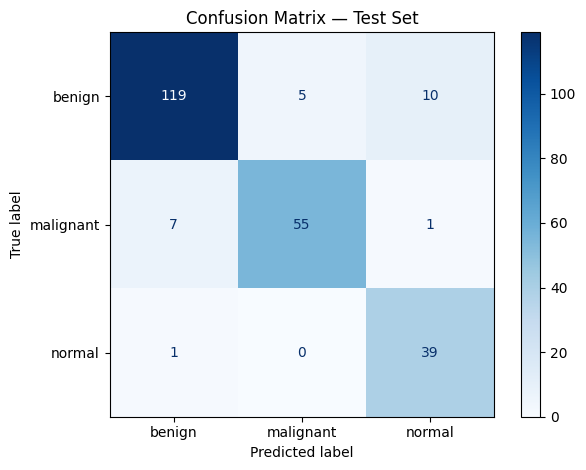

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels_batch in test_loader:
        preds = model(images.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=label_names))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(cmap='Blues')
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

---
## Stage 7 — Load Model & Run Inference

Load the saved weights and run predictions on new images — same pattern a deployed service would use.

In [ ]:
# # Reload model from saved weights
# loaded_model = build_model(NUM_CLASSES)
# loaded_model.load_state_dict(torch.load("resnet18_ultrasound.pt", map_location=device))
# loaded_model.eval()

# def predict_image(pil_image):
#     """Predict class for a single PIL image."""
#     tensor = eval_transform(pil_image.convert('L')).unsqueeze(0).to(device)
#     with torch.no_grad():
#         probs = torch.softmax(loaded_model(tensor), dim=1).squeeze().cpu().numpy()
#     pred_idx = probs.argmax()
#     return {
#         "prediction":  label_names[pred_idx],
#         "confidence":  round(float(probs[pred_idx]), 3),
#         "class_probs": {label_names[i]: round(float(p), 3) for i, p in enumerate(probs)}
#     }

# # Show predictions on 4 test images
# fig, axes = plt.subplots(1, 4, figsize=(14, 4))
# for ax, idx in zip(axes, range(4)):
#     ex     = test_data[idx]
#     result = predict_image(ex[IMAGE_FIELD])
#     true   = label_names[ex[LABEL_FIELD]]
#     color  = 'green' if result['prediction'] == true else 'red'

#     ax.imshow(ex[IMAGE_FIELD], cmap='gray')
#     ax.set_title(
#         f"True: {true}\nPred: {result['prediction']} ({result['confidence']:.0%})",
#         fontsize=9, color=color
#     )
#     ax.axis('off')

# plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=11)
# plt.tight_layout()
# plt.show()

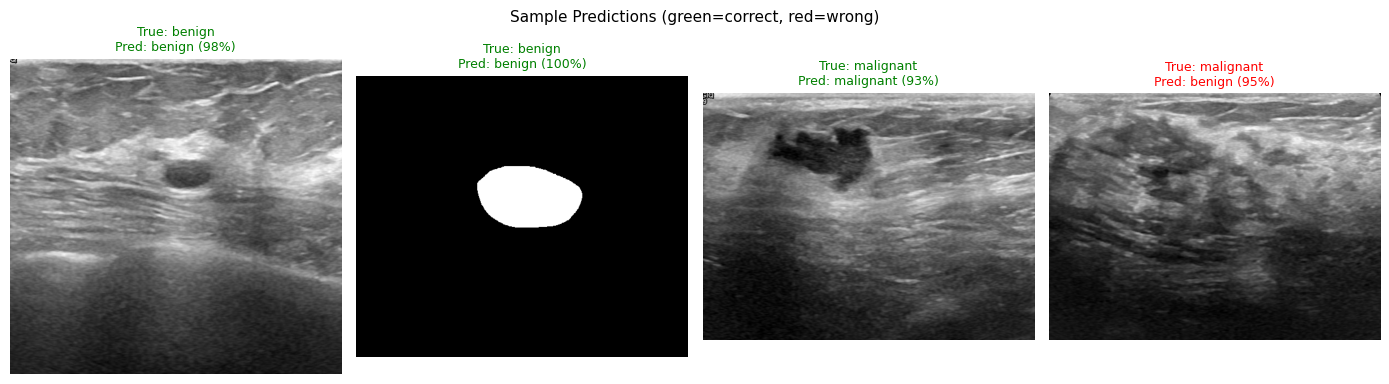

In [ ]:
# Reload model from saved weights
loaded_model = build_model(NUM_CLASSES)
loaded_model.load_state_dict(torch.load("mobilenetv2_ultrasound.pt", map_location=device))  # ← updated
loaded_model.eval()

def predict_image(pil_image):
    """Predict class for a single PIL image."""
    tensor = eval_transform(pil_image.convert('L')).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(loaded_model(tensor), dim=1).squeeze().cpu().numpy()
    pred_idx = probs.argmax()
    return {
        "prediction":  label_names[pred_idx],
        "confidence":  round(float(probs[pred_idx]), 3),
        "class_probs": {label_names[i]: round(float(p), 3) for i, p in enumerate(probs)}
    }

# Show predictions on 4 test images
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, range(4)):
    ex     = test_data[idx]
    result = predict_image(ex[IMAGE_FIELD])
    true   = label_names[ex[LABEL_FIELD]]
    color  = 'green' if result['prediction'] == true else 'red'

    ax.imshow(ex[IMAGE_FIELD], cmap='gray')
    ax.set_title(
        f"True: {true}\nPred: {result['prediction']} ({result['confidence']:.0%})",
        fontsize=9, color=color
    )
    ax.axis('off')

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.show()

Save Model to Drive:

In [ ]:
torch.save(model.state_dict(), "mobilenetv2_ultrasound.pt")
# Add this line:
!cp mobilenetv2_ultrasound.pt "/content/drive/MyDrive/indabax_models/mobilenetv2_ultrasound.pt"

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
